<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


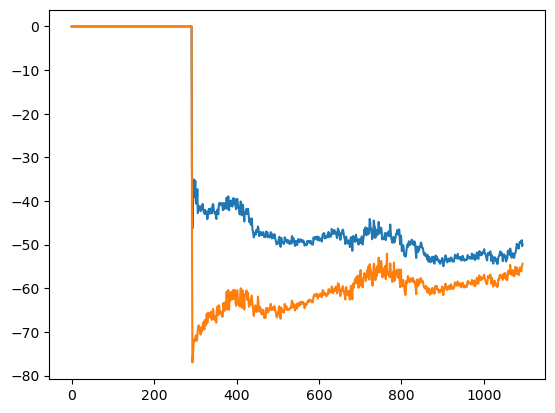

In [6]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt

for casename in ['20250429_HBR_ICB20TRCNPRDCTCBC_z0mrerw',
                 '20250624_HBR_ICB20TRCNPRDCTCBC_z0mr_veryLowRateerw']:
    hr = xr.open_mfdataset([
        os.path.join(os.environ['E3SM_ROOT'], 'output', casename,
                    'run', f'{casename}.elm.h1.{year}-01-01-00000.nc') \
        for year in range(1999, 2002)])

    # \Delta G = RT * ln(Q/Ksp)
    dG = (hr['log_omega_vr_1'][:,0,0] * np.log(10) * (8.314 / 1000) * hr['TBOT'][:,0]).values

    plt.plot(dG)

    hr.close()

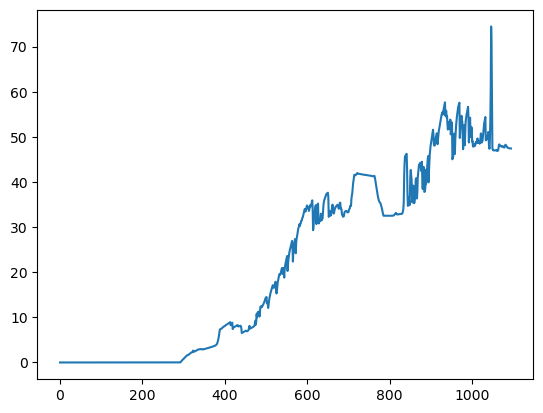

In [7]:
plt.plot(hr['silica_vr'][:,0,0].values / hr['H2OSOI'][:,0,0].values / 60)

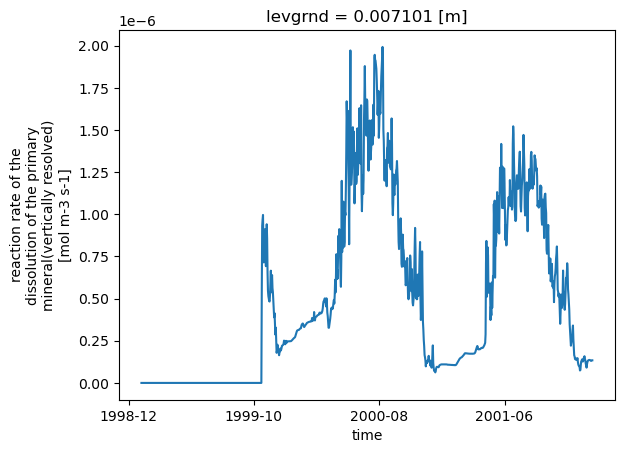

In [8]:
hr['r_dissolve_vr_1'][:,0,0].plot()

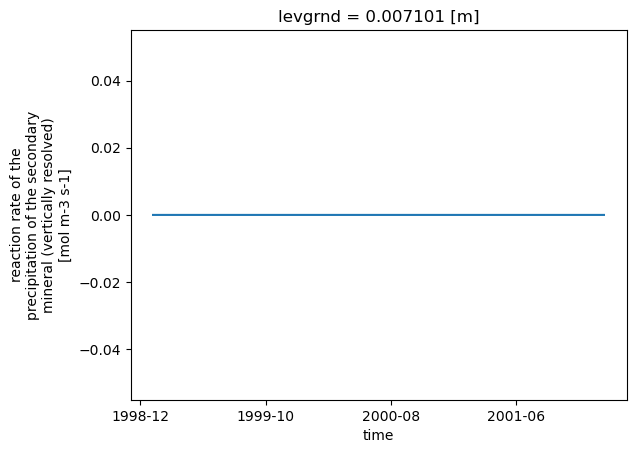

In [9]:
hr['r_precip_vr_1'][:,0,0].plot()

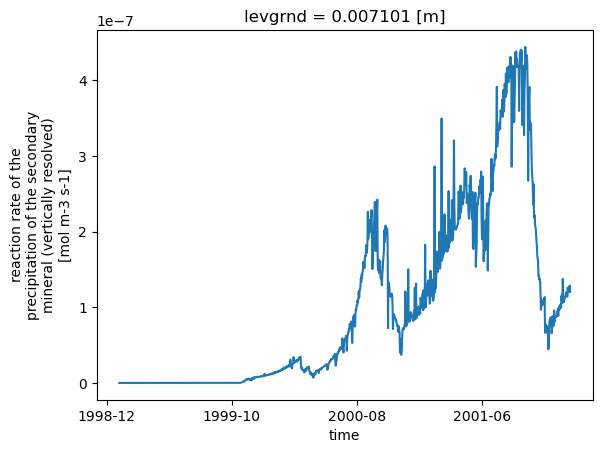

In [10]:
hr['r_precip_vr_2'][:,0,0].plot()

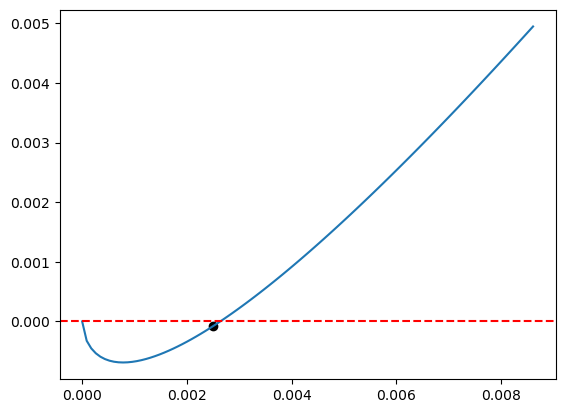

In [23]:
# Calcite precipitation passivation equation in the paper:
#
# A_eff(t) = SSA_0 * n_{w0}(t) - k_p^' n_{CaCo3}(t)^{2/3}
# 
# where A_eff(t) is the effective surface area at time t, 
# SSA_0 is the initial specific surface area, 
# n_{w0}(t) is the number of mols of dissolving wollastonite at time t,
# k_p^' is a rate constant, and n_{CaCo3}(t) is the number of mols of precipitating calcite at time t.
#
# In their application case, they have:
# SSA_0 = 0.066 m^2/g, k_p^' = 0.29, n_{CaCO3}(t) = n_{w0}(t) * 0.77, 
# and initial mass n_0 = ~2.5*10^{-3} mol
# 
# Daval, Damien, Isabelle Martinez, Jérôme Corvisier, Nathaniel Findling, Bruno Goffé, and François Guyot. 2009. “Carbonation of Ca-Bearing Silicates, the Case of Wollastonite: Experimental Investigations and Kinetic Modeling.” Chemical Geology 265 (1–2): 63–78. https://doi.org/10.1016/j.chemgeo.2009.01.022.
import scipy.optimize as opt

# gram to mol conversion for CaSiO3
mass = 116.1617

def target(x):
    return (x-x*0.77)*0.066*mass - 0.29*(x*0.77)**(2/3)

plt.plot(np.linspace(0, 1/mass, 100), target(np.linspace(0, 1/mass, 100)))
plt.axhline(0, color='r', linestyle='--')
plt.scatter(2.5e-3, target(2.5e-3), color='k', label='initial n_0')

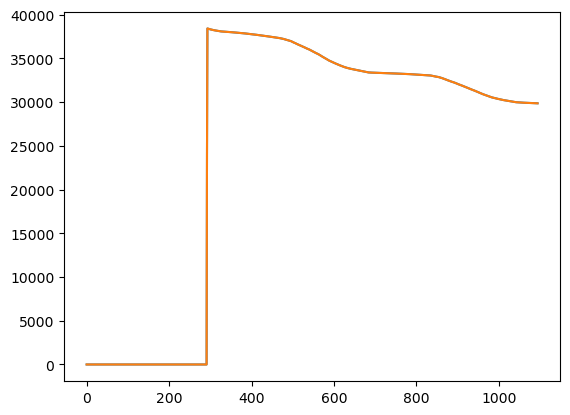

In [ ]:
# Apply the above equation on my data
# Not working!

ssa = hr['ssa'][:,0,0].values
mol0 = hr['primary_mineral_vr_1'][:,0,0] / mass
#mol_sec = hr['secondary_mineral_vr_2'][:,0,0] / 258.1604
mol_sec = hr['silica_vr'][:,0,0] / 60.0843  # molar mass of SiO2

plt.plot(mol0*ssa*mass, label = 'Original dissolution rate')
plt.plot(mol0*ssa*mass - 0.29*mol_sec**(2/3), label = 'Passivated dissolution rate')

In [ ]:
# Try another passivation model
# This one should work !!!!!!!!!!!!!!!!! 
# Emmanuel, Simon. 2022. “Modeling the Effect of Mineral Armoring on the Rates of Coupled Dissolution-Precipitation Reactions: Implications for Chemical Weathering.” Chemical Geology 601 (July):120868. https://doi.org/10.1016/j.chemgeo.2022.120868.


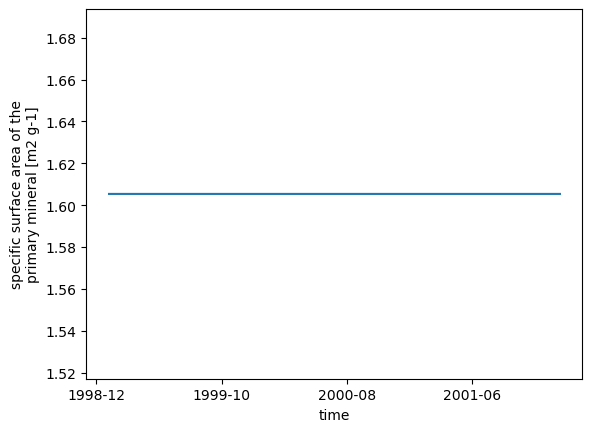

In [27]:
hr['ssa'][:,0,0].plot()
